# Dogs of the Dow — a quantitative teardown 🔬
### Point-in-time universe · HAC + block-bootstrap on the annual excess · alpha-vs-beta

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We separate the two things the Dogs do — **tilt toward cheap, high-yield, lower-beta names** (real, and a known risk premium) and **beat the Dow** (not certifiable on this tape) — and show the headline gap is a defensive value tilt the screen can't certify as alpha.

> ⚠️ **Not investment advice.** Dow components, daily, total-return adjusted + the dividend stream (`yfinance`), point-in-time membership encoded in `dogs_of_the_dow/data.py`; benchmark DIA total return; 20 bps/turnover. Sources in [`docs/references.md`](../docs/references.md), reproducible run in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (dogs_of_the_dow/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from dogs_of_the_dow import data, strategy

AS_OF = "2026-06-13"
CACHE = os.path.abspath(os.path.join("..", "_cache"))
panel = data.load_panel(end=AS_OF, cache_dir=CACHE)
ann = strategy.annual_returns_from_panel(panel, 2000, 2025, cost_bps=20.0)
summ = strategy.summarize(ann)
exc = ann["excess"].to_numpy()
hac_t = strategy.hac_tstat(exc)
boot = strategy.block_bootstrap_ci(exc)
ab = strategy.alpha_beta(ann)
print(f"Dow panel: {panel['prices'].shape[1]} tickers x {len(panel['prices']):,} days  fingerprint={data.fingerprint(panel)}")
print(f"Dogs CAGR {summ['dogs_cagr']*100:.2f}%  vs Dow {summ['dow_cagr']*100:.2f}%  gap {summ['cagr_gap']*100:+.2f} pts/yr  ({summ['n_years']} yrs)")
print(f"HAC t {hac_t:+.2f}   alpha {ab['alpha']*100:+.2f}%/yr (t {ab['alpha_t']:+.2f})   beta {ab['beta']:.2f}")


$EK: possibly delisted; no price data found  (1d 1927-07-08 -> 2026-06-13)


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}


$WBA: possibly delisted; no timezone found


Dow panel: 46 tickers x 6,673 days  fingerprint=6dfd9e54cba6
Dogs CAGR 8.51%  vs Dow 7.54%  gap +0.98 pts/yr  (26 yrs)
HAC t +0.59   alpha +2.58%/yr (t +1.59)   beta 0.80


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | `WEAK` | +1.0 pts/yr over 26 point-in-time years, but **HAC *t* = +0.59** and a block-bootstrap CI **[-2.15%, +3.59%]** (*p* = 0.51). Alpha **+2.58%/yr** but *t* = **1.59** (sub-2); **beta 0.8** — a defensive value tilt, not certified alpha. |
| **Tradability** | `FRAGILE` | Turnover ~23%/yr → trading cost barely bites, but the high-yield basket carries an annual **dividend-tax drag** and **dividend-trap** risk; a sub-2-*t* ~1-pt gap doesn't survive it. |

> 💡 **In plain words:** the Dogs are a *value/high-yield tilt that works as a tilt* wearing the costume of a *Dow-beating secret that the statistics can't confirm*.

## 1 · The claim, steelmanned

- **H₁ (tilt):** the Dogs are a high-yield / value / lower-beta slice of the Dow.
- **H₂ (the sold claim):** the Dogs beat the Dow on total return, net, out of sample.
- **H₃ (alpha):** the excess survives controlling for the Dow itself (an intercept *t* > 2).

H₁ can be true while H₂ is only marginal and H₃ fails — which is exactly what we find.

## 2 · So what? — what rides on each answer

If H₃ held, a no-skill mechanical screen would deliver certified alpha over the most-watched index on earth. It doesn't — and seeing *why* (a sub-2-*t* gap that is mostly sub-1 beta) is the lesson.

## 3 · How we'd know — the protocol

Point-in-time universe (no survivorship) · annual rebalanced total-return engine vs same-basis DIA · HAC *t* and circular block bootstrap on the annual excess · alpha-vs-beta OLS · cost/turnover/tax capacity read.

## 4 · The teardown

The annual table — Dogs, Dow, and the excess, net of 20 bps/turnover:

In [2]:
show = ann.copy()
for c in ['dogs', 'dow', 'excess']: show[c] = (show[c]*100).round(2)
show[['dogs', 'dow', 'excess', 'n_names', 'turnover']]

,dogs,dow,excess,n_names,turnover
year,,,,,
2000,14.500,-4.650,19.150,10,1.000
2001,-6.690,-4.640,-2.050,10,0.100
2002,-9.680,-15.580,5.910,10,0.100
2003,30.830,23.940,6.890,10,0.200
2004,10.210,5.220,4.990,10,0.100
2005,1.780,1.790,-0.010,10,0.300
2006,20.370,17.400,2.970,10,0.100
2007,5.860,8.740,-2.880,10,0.100
2008,-32.000,-31.140,-0.870,10,0.200


**Inference on the annual excess** — HAC *t* and a circular block bootstrap (26 obs is short, so the bootstrap is honest about its own power):

In [3]:
lo, hi, p = boot
print(f'mean annual excess = {exc.mean()*100:+.2f}%/yr   win rate {(exc>0).mean()*100:.0f}%')
print(f'HAC t              = {hac_t:+.2f}   (|t| < 2 -> cannot reject zero)')
print(f'block-bootstrap 95% CI = [{lo*100:+.2f}%, {hi*100:+.2f}%]   two-sided p = {p:.2f}')
print('=> the annual edge is statistically indistinguishable from zero on this tape.')

mean annual excess = +0.87%/yr   win rate 54%
HAC t              = +0.59   (|t| < 2 -> cannot reject zero)
block-bootstrap 95% CI = [-2.15%, +3.59%]   two-sided p = 0.51
=> the annual edge is statistically indistinguishable from zero on this tape.


> 💡 **In plain words:** over 26 years the Dogs' lead is small enough, and bounces around enough, that we can't tell it apart from luck.

**Alpha vs beta** — regress the Dogs' return on the Dow's. Is any edge real alpha, or just exposure?

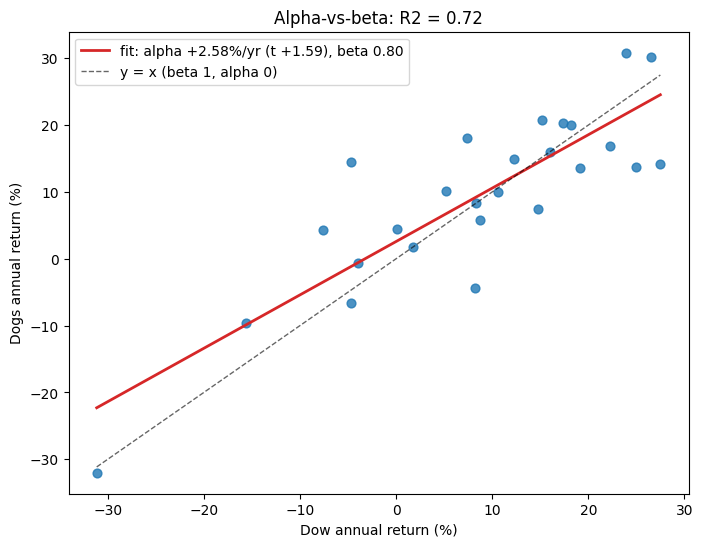

alpha +2.58%/yr (t +1.59)   beta 0.80   R2 0.72


In [4]:
x = ann['dow'].to_numpy()*100; y = ann['dogs'].to_numpy()*100
xs = np.linspace(x.min(), x.max(), 50)
fig, axx = plt.subplots(figsize=(8, 6))
axx.scatter(x, y, s=40, alpha=.8)
axx.plot(xs, ab['alpha']*100 + ab['beta']*xs, 'C3', lw=2, label=f"fit: alpha {ab['alpha']*100:+.2f}%/yr (t {ab['alpha_t']:+.2f}), beta {ab['beta']:.2f}")
axx.plot(xs, xs, 'k--', lw=1, alpha=.6, label='y = x (beta 1, alpha 0)')
axx.set_xlabel('Dow annual return (%)'); axx.set_ylabel('Dogs annual return (%)')
axx.set_title(f"Alpha-vs-beta: R2 = {ab['r2']:.2f}"); axx.legend(); plt.show()
print(f"alpha {ab['alpha']*100:+.2f}%/yr (t {ab['alpha_t']:+.2f})   beta {ab['beta']:.2f}   R2 {ab['r2']:.2f}")

> 💡 **In plain words:** the Dogs move with the Dow but a touch *less* violently (beta 0.80) — they're the defensive, high-yield corner of the index. The bit of return left over after that (the alpha) is positive but not big enough to be sure it isn't noise.

## 5 · The verdict

Signal `WEAK` (gap +1.0 pts/yr, HAC *t* 0.59, bootstrap CI [-2.15%, +3.59%]; alpha +2.58%/yr at *t* 1.59, beta 0.8). Tradability `FRAGILE` (low turnover, but annual dividend-tax drag + dividend-trap risk on a sub-2-*t* gap). The edge is a defensive value tilt, not certified alpha.

## 6 · Could you trade it?

Capacity is a non-issue (Dow blue chips, infinite liquidity; ~23%/yr turnover). The binding facts are economic, not frictional: (1) the ~1-pt gross gap is **not statistically real**; (2) what tilt is real is **beta 0.80** value exposure, replicable with any cheap high-dividend ETF; (3) the basket is built to be **high-yield**, so a taxable investor eats an annual dividend-income tax the cap-weighted Dow holder largely defers. Net of tax the after-tax race is a wash.

## 7 · Going further

- Re-run on a **forward / cut-adjusted yield** to neutralize the dividend traps the trailing screen buys (Citi, BofA in Jan-2009) — does a cleaner screen recover a *t* > 2?
- **After-tax** backtest: charge qualified-dividend and rebalancing tax explicitly and recompute the gap.
- The **two named omissions** (Kodak 2000-04, Walgreens 2019-24): bound their worst-case impact by inserting plausible high-yield proxies and re-stamping — does the verdict move?